# 机器学习

## 散点图

In [1]:
import pandas as pd
df_ads = pd.read_csv('易速鲜花微信软文.csv')
df_ads.head(10)

,点赞数,转发数,热度指数,文章评级,浏览量
0,2646,1347.0,7,5,260004
1,816,816.0,4,6,100004
2,1224,612.0,6,5,164502
3,1261,1261.0,6,6,163001
4,1720,1720.0,7,5,260401
5,1541,1541.0,7,5,220002
6,827,NaN,5,7,107503
7,866,686.0,5,9,110504
8,1314,1300.0,8,5,229461
9,1431,1099.0,6,5,165004


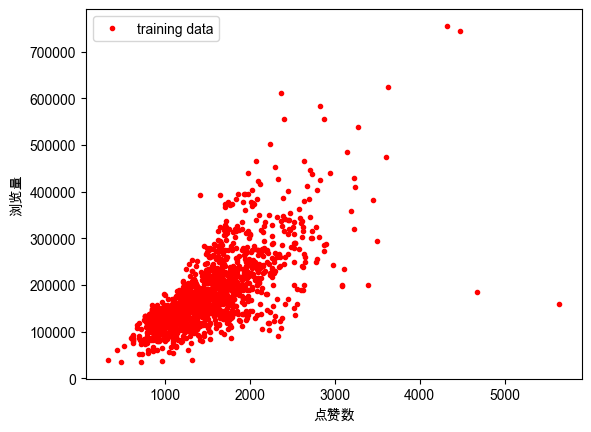

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

import matplotlib as mpl
mpl.rcParams['font.family'] = 'Arial Unicode MS' # 设置中文字体支持

plt.plot(df_ads['点赞数'], df_ads['浏览量'], 'r.', label = 'training data')
plt.xlabel('点赞数')
plt.ylabel('浏览量')
plt.legend()
plt.show()

## 箱线图

(np.float64(-0.5), np.float64(9.5), np.float64(0.0), np.float64(800000.0))

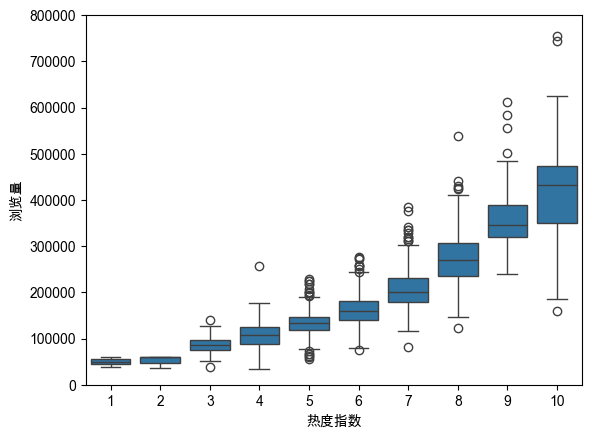

In [3]:
data = pd.concat([df_ads['浏览量'], df_ads['热度指数']], axis = 1)
fig = sns.boxplot(x='热度指数', y='浏览量', data = data)
fig.axis(ymin=0, ymax=800000)

## 数据清洗

In [4]:
df_ads.isna().sum()

点赞数      0
转发数     37
热度指数     0
文章评级     0
浏览量      0
dtype: int64

In [5]:
df_ads = df_ads.dropna()

## 特征工程

BMI 指数

 $$BMI = \frac{体重(kg)}{身高(m)^2}$$




## 构建特征集和标签集



In [6]:
X = df_ads.drop(['浏览量'], axis=1) # 特征集

y = df_ads.浏览量 # 标签集

X.head()

,点赞数,转发数,热度指数,文章评级
0,2646,1347.0,7,5
1,816,816.0,4,6
2,1224,612.0,6,5
3,1261,1261.0,6,6
4,1720,1720.0,7,5


In [7]:
y.head()

0    260004
1    100004
2    164502
3    163001
4    260401
Name: 浏览量, dtype: int64

## 拆分训练集、验证集和测试集

测试 20% - 30%

In [8]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=0)

## 选择算法建立模型

In [9]:
from sklearn.linear_model import LinearRegression
model1 = LinearRegression()


## 训练模型

In [10]:
model1.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](4,)","[ 48.08, 34.73,29730.13, 2949.62]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](4,)","['点赞数','转发数','热度指数','文章评级']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-1.275e+05
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,4
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,4


## 模型评估和优化

In [11]:
y_pred = model1.predict(X_test)

In [12]:
df_ads_pred = X_test.copy()
df_ads_pred['浏览量真实值'] = y_test
df_ads_pred['浏览量预测值'] = y_pred
df_ads_pred

,点赞数,转发数,热度指数,文章评级,浏览量真实值,浏览量预测值
1074,1709,970.0,6,5,130003,181499.180492
404,1440,1440.0,4,4,118005,122478.101604
1375,1434,1454.0,7,5,189003,214815.847941
1317,832,832.0,6,6,105504,137486.350468
145,923,876.0,5,5,119501,110710.382414
...,...,...,...,...,...,...
420,1790,873.0,7,5,193004,211755.243385
1338,2622,1463.0,8,5,325002,301982.291922
542,1342,1372.0,6,5,161502,177814.080182
311,1663,1364.0,4,6,256002,136460.539585


In [14]:
print('当前模型的权重是：', model1.coef_)
print('当前模型的偏置是：', model1.intercept_)

当前模型的权重是： [   48.08395224    34.73062229 29730.13312489  2949.62196343]
当前模型的偏置是： -127493.90606857196


In [15]:
print('线性回归预测评分：', model1.score(X_test, y_test))

线性回归预测评分： 0.740552064611524
